<a href="https://colab.research.google.com/github/LuOrdonez/Portfolio/blob/Laboratorio/Conteo_estadistico_fotones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importo librerias y parámetros

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, re
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import factorial
from tqdm import tqdm


# ====== Estilo global ======
plt.rcParams.update({'legend.fontsize': 22})
plt.rcParams.update({'axes.titlesize': 22})
plt.rcParams.update({'axes.labelsize': 24})
plt.rcParams.update({'ytick.labelsize': 24})
plt.rcParams.update({'xtick.labelsize': 24})
plt.rcParams.update({'legend.loc': "best"})
plt.rcParams.update({"figure.figsize": [9, 7]})
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.grid'] = True # Corrected: Removed the invalid assignment of 'alpha'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['grid.alpha'] = 0.5


#Cargo data


In [ ]:
!gdown 1zizzB86pggL6hvs24dLHFgOiJMAMmeCR  -O laser1500.csv


Downloading...
From (original): https://drive.google.com/uc?id=1zizzB86pggL6hvs24dLHFgOiJMAMmeCR
From (redirected): https://drive.google.com/uc?id=1zizzB86pggL6hvs24dLHFgOiJMAMmeCR&confirm=t&uuid=d5b2fded-d6fa-41a9-9fae-971b04caad57
To: /content/laser1500.csv
100% 442M/442M [00:06<00:00, 73.1MB/s]


In [ ]:
total_pantallas = 1500

tiempo = []
voltaje = []

data='/content/laser1500.csv'
df=pd.read_csv(data)

tiempo_entero = df['Time']
voltaje_entero = df['Voltaje fuente']

for n in tqdm(range(total_pantallas+1)):
    df_pantallas = df[df["Pantalla"]== n]
    t = df_pantallas['Time_local']
    v = df_pantallas['Voltaje fuente']

    tiempo.append(t)
    voltaje.append(v)

tiempo = np.array(tiempo[1:])
voltaje = np.array(voltaje[1:])

100%|██████████| 1501/1501 [00:11<00:00, 135.26it/s]


#Definición de umbral

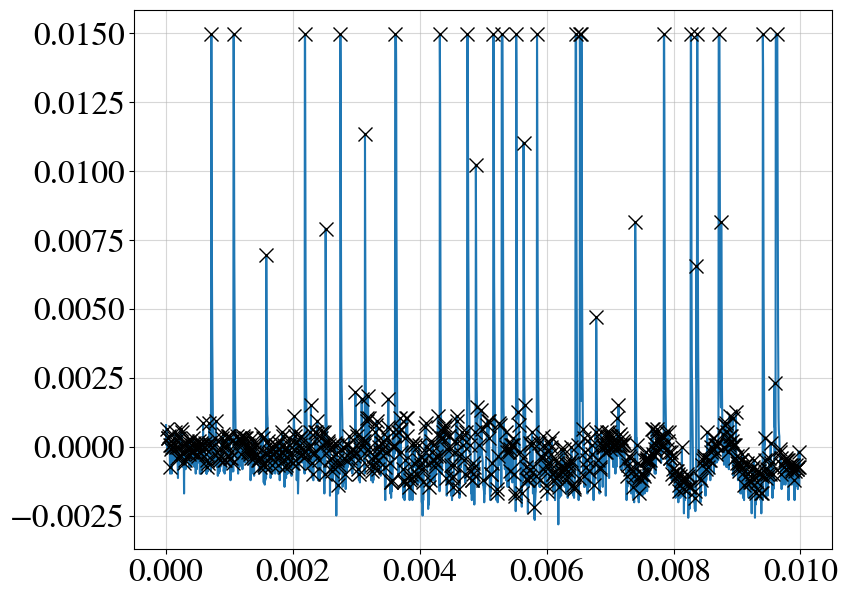

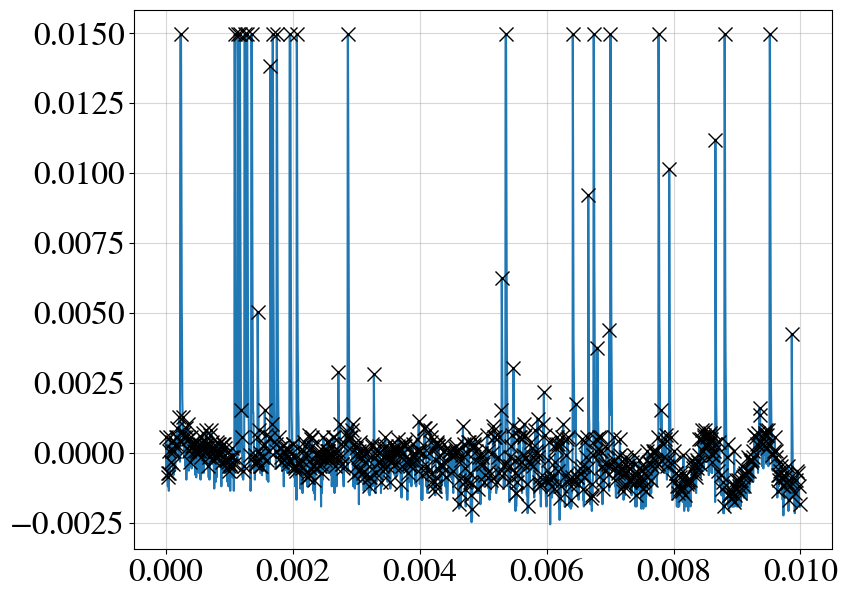

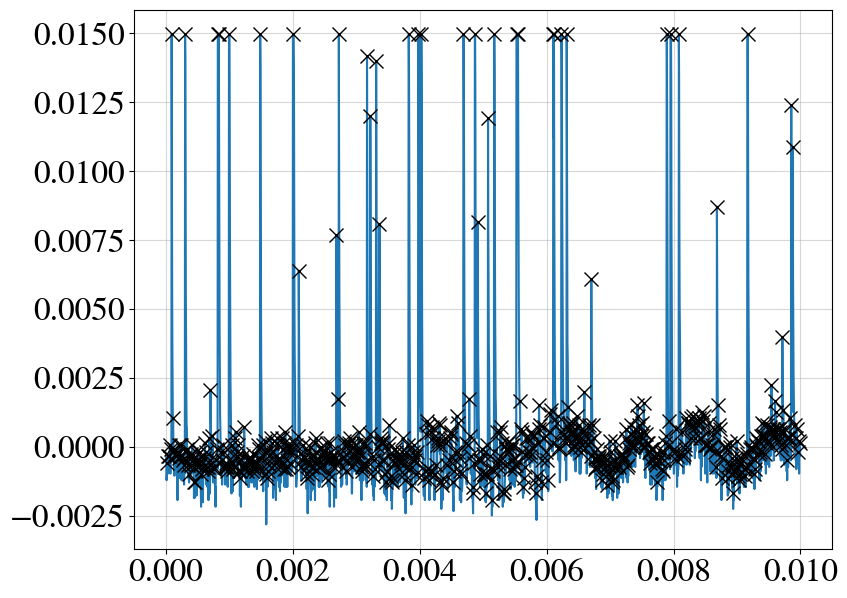

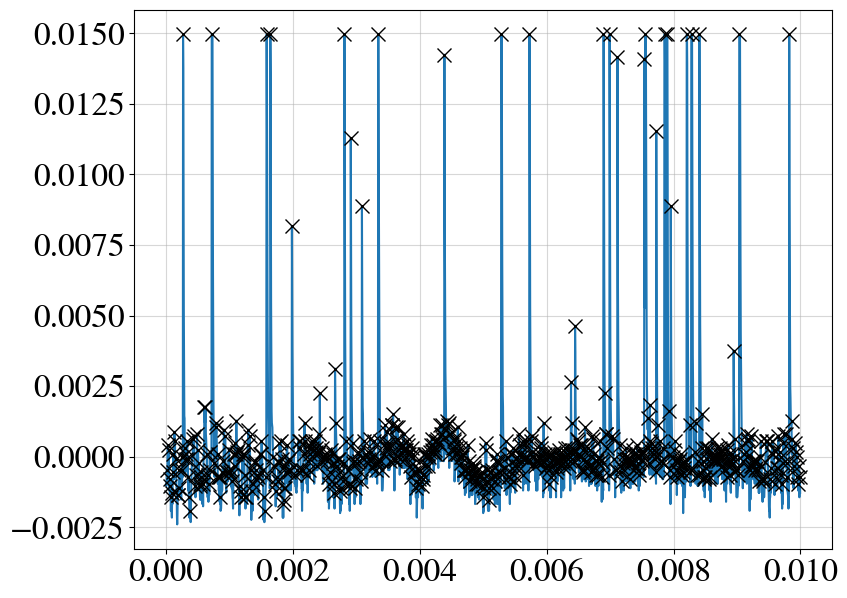

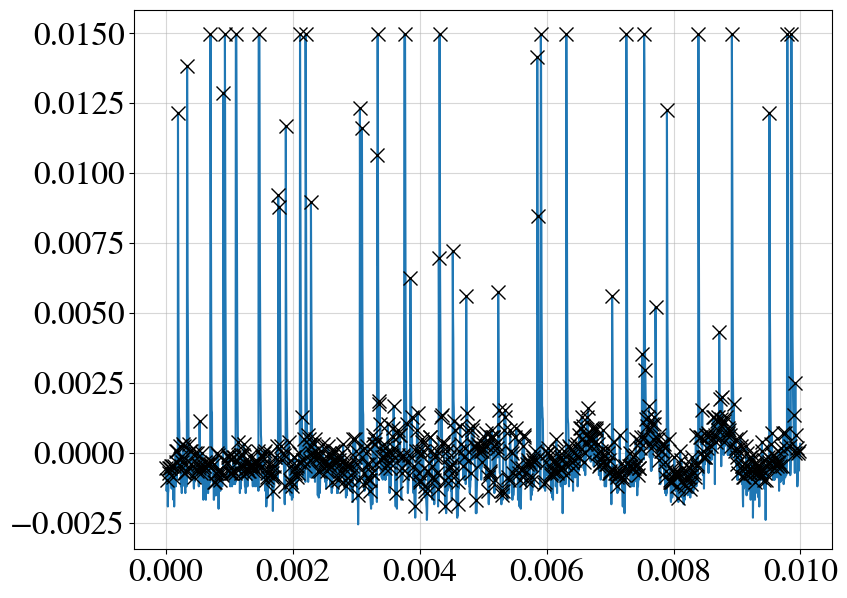

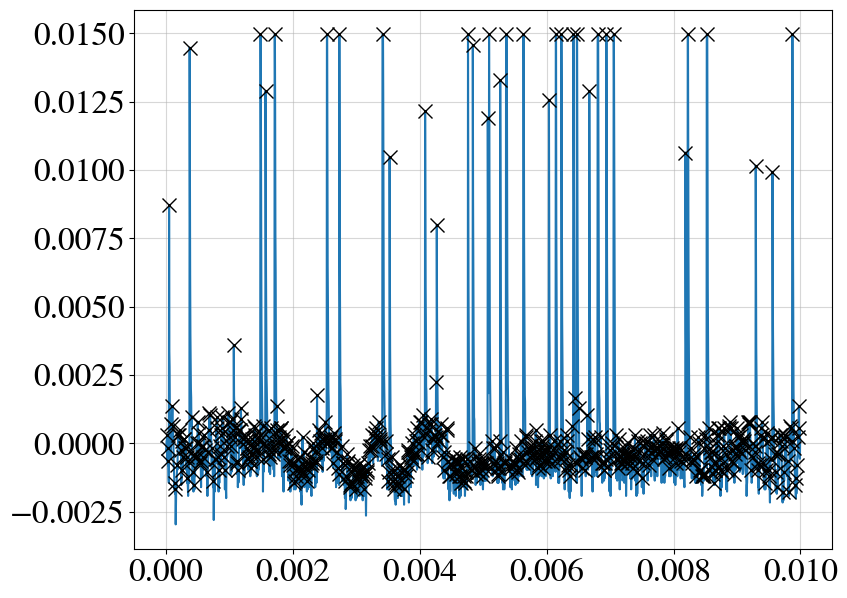

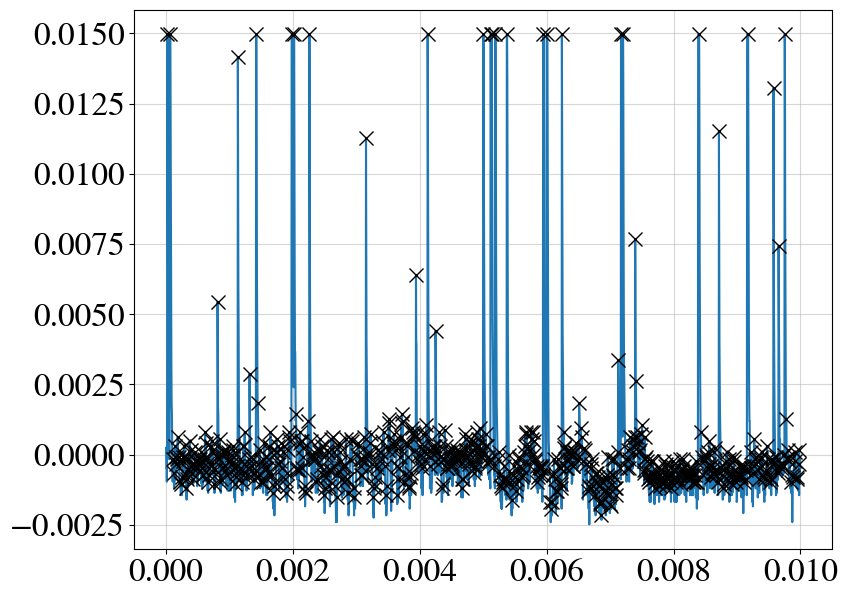

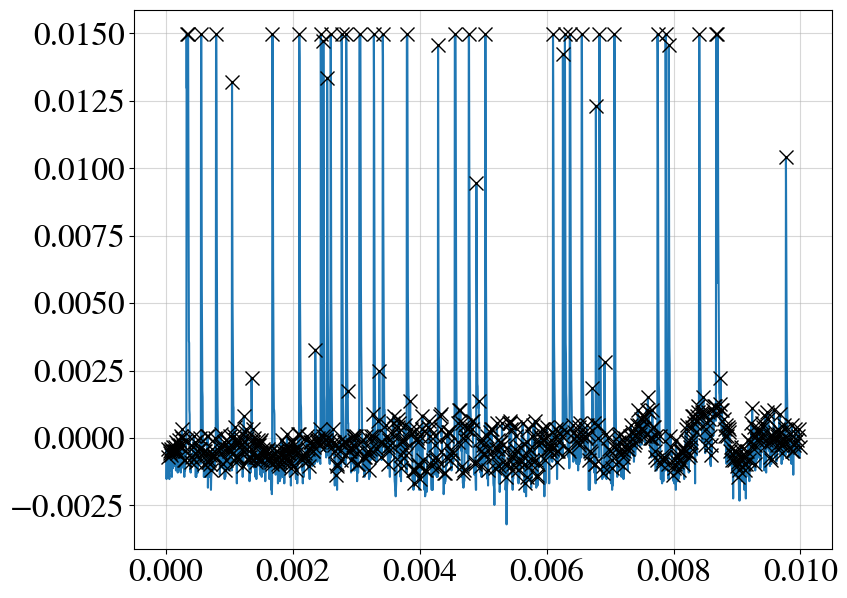

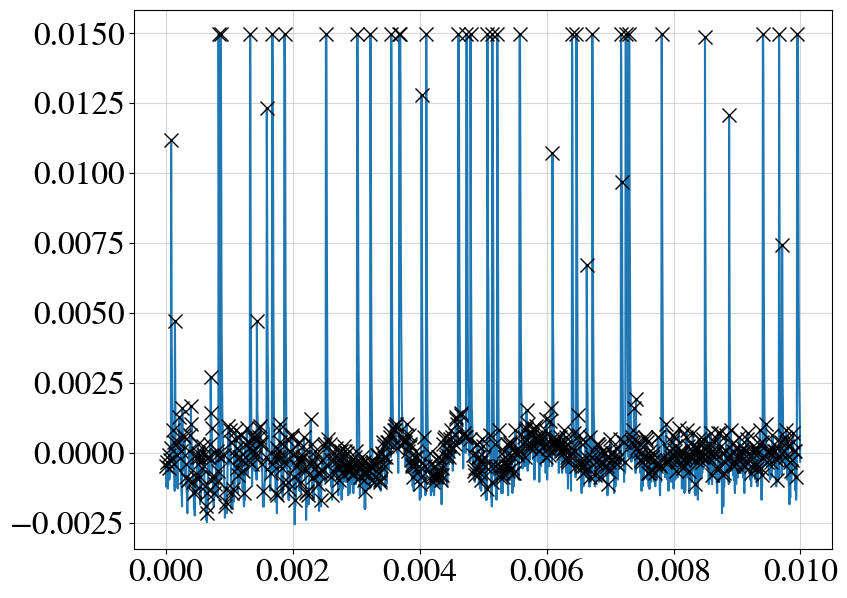

In [ ]:
alturas_umbral = []

for n in np.arange(1,total_pantallas, 1):
    picos, diccionario = find_peaks(-voltaje[n])

    #para evitar un segundo pico en el valor de saturación
    picos_sin_sat = []
    for k in range(len(picos)):
        if -voltaje[n][picos[k]] < 0.014:
            picos_sin_sat.append(picos[k])

        else:
            continue
    alturas_umbral.append(voltaje[n][picos_sin_sat])

    if n < 10:
        plt.plot(tiempo[n], - voltaje[n])
        plt.plot(tiempo[n][picos], -voltaje[n][picos], marker = 'x', markersize = 10, color = 'black', linestyle = '')
        plt.show()





0.00216


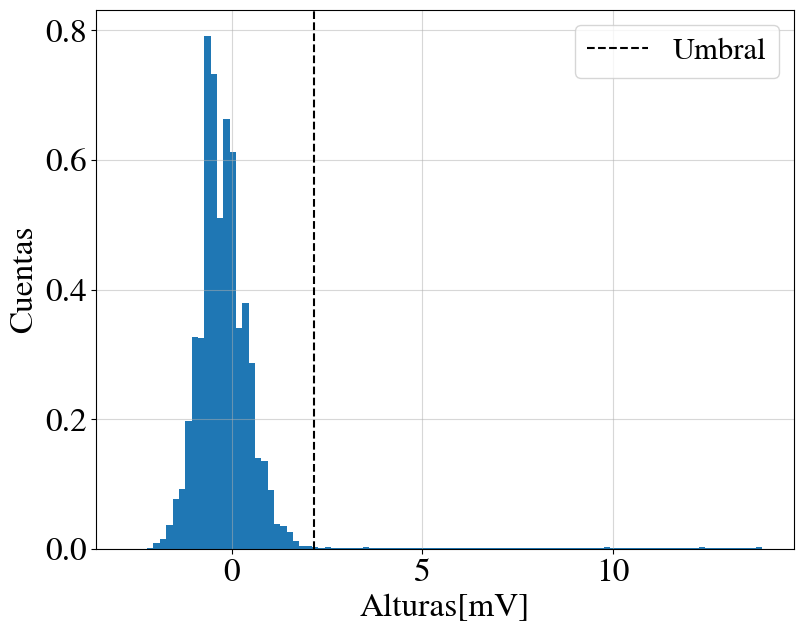

In [ ]:
cuentas_umbral_junto = np.concatenate(alturas_umbral)

#definimos el umbral como el valor para el cual si aparece un pico va a tener 0.01% de prob de ser ruido
umbral = np.percentile(cuentas_umbral_junto, 99.99)

print(umbral)

plt.hist(-cuentas_umbral_junto*1000, bins = 100, density = True )
plt.axvline(umbral*1000, color = 'black', linestyle = '--', label = 'Umbral')

plt.xlabel('Alturas[mV]')
plt.ylabel('Cuentas')

plt.legend()
plt.show()

#Cuentas

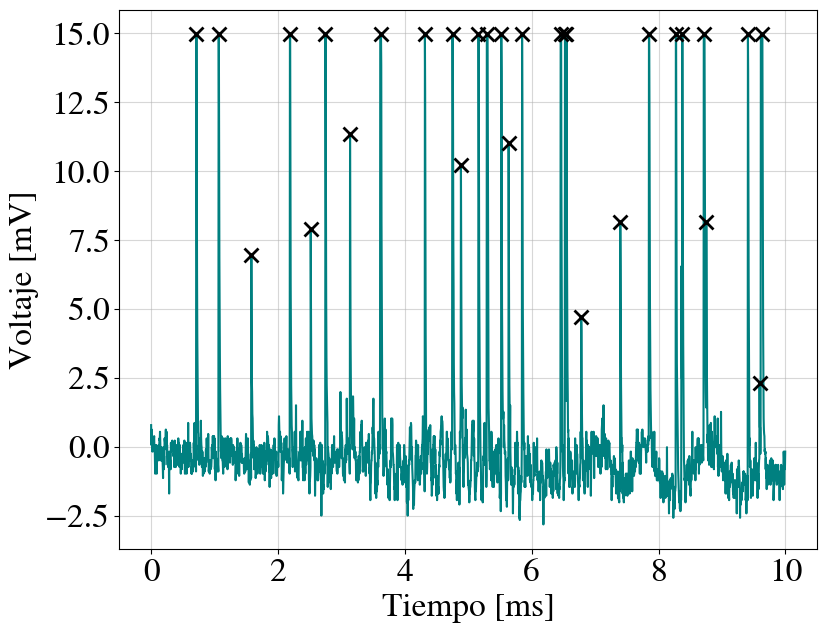

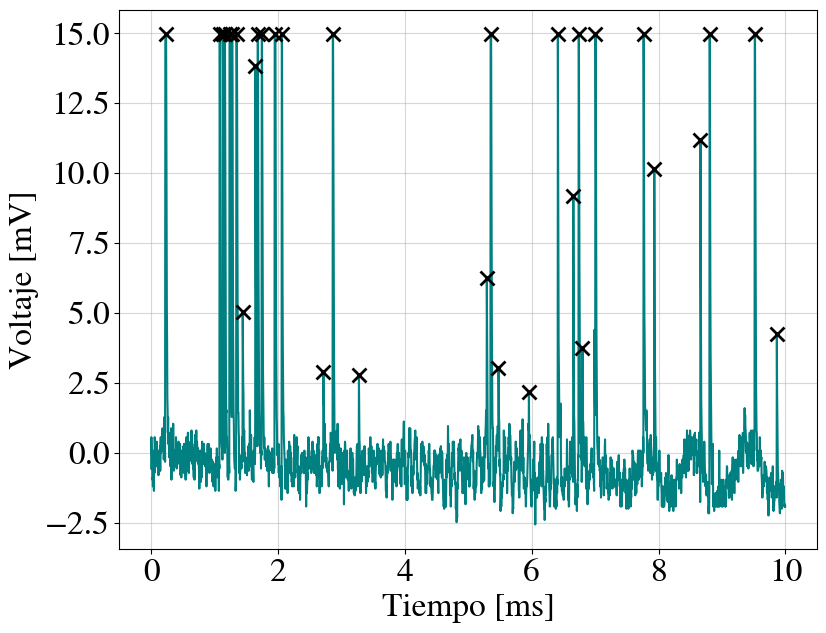

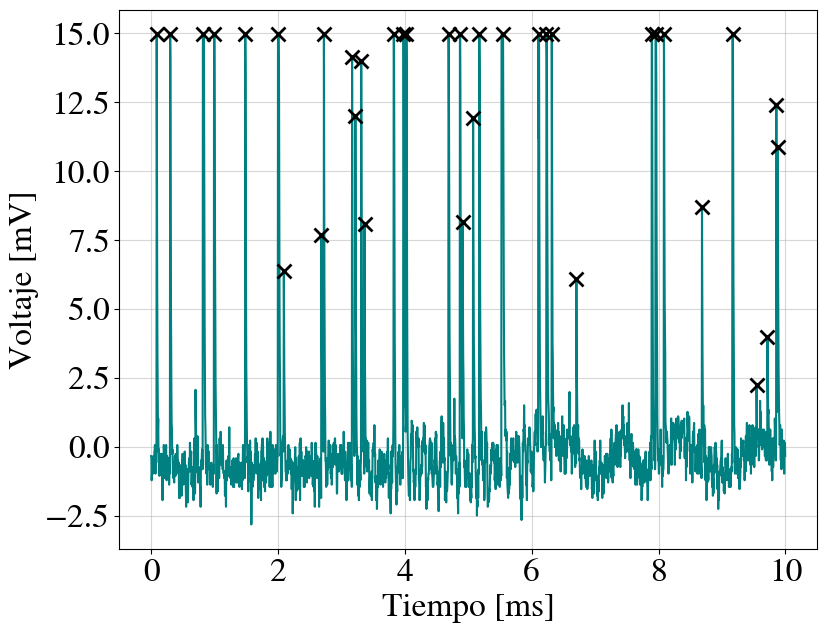

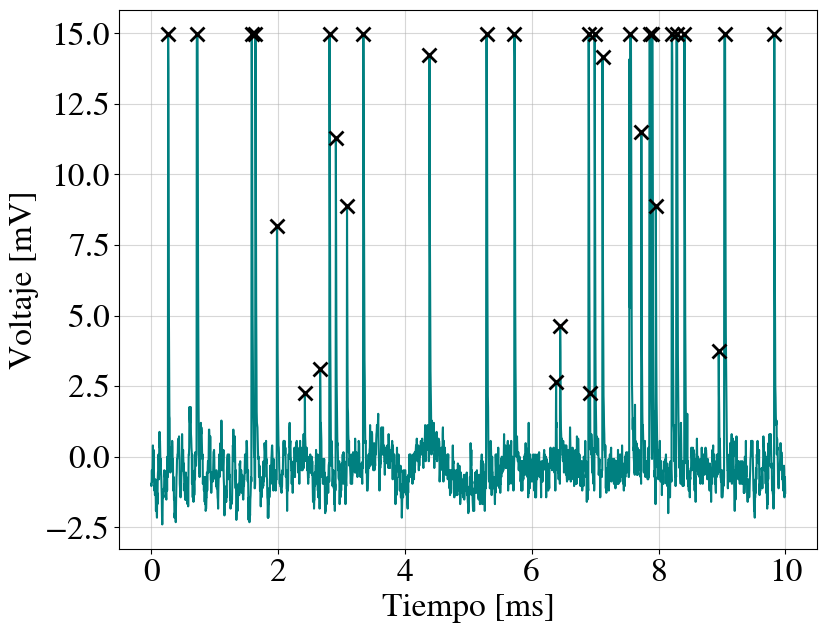

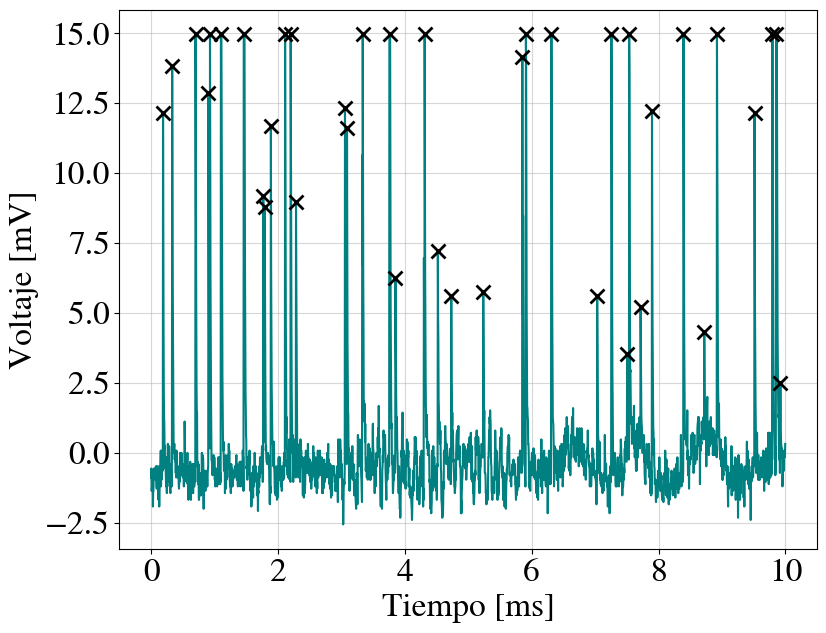

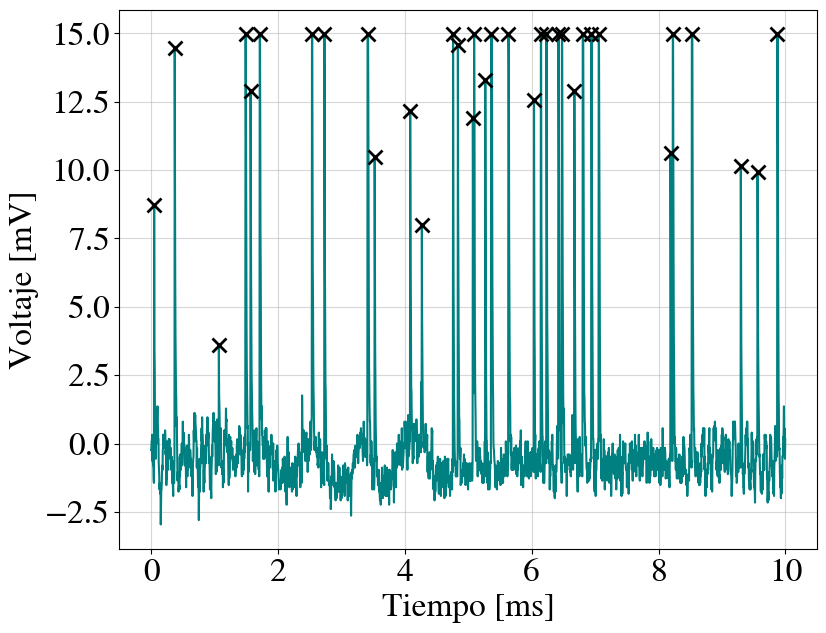

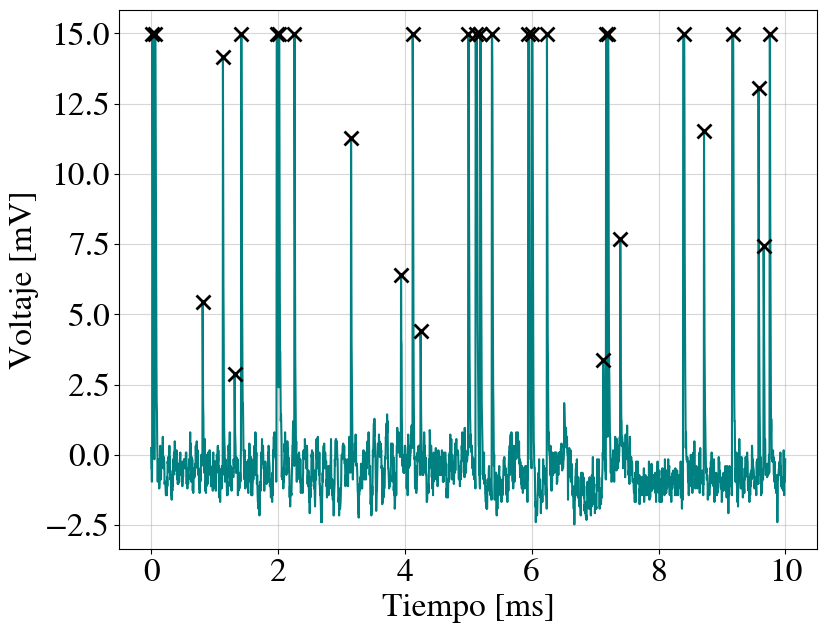

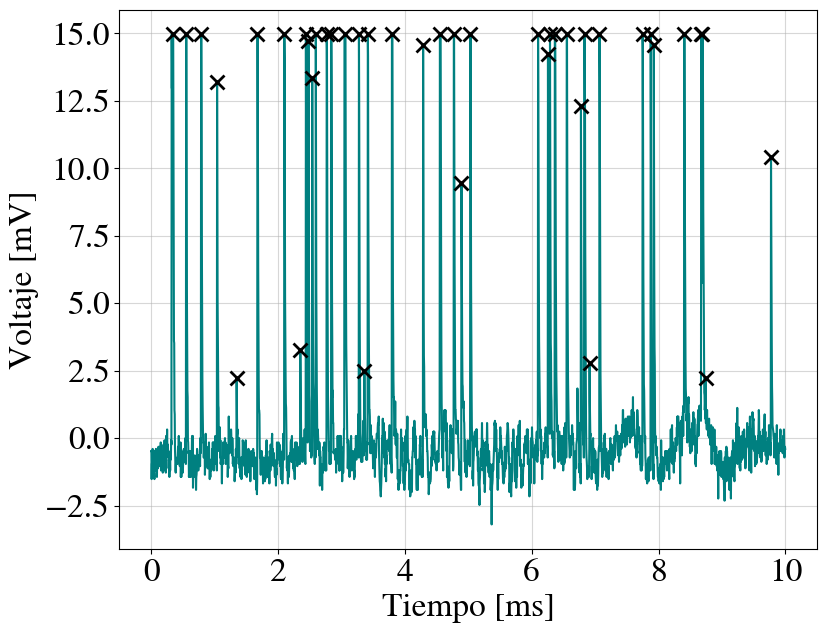

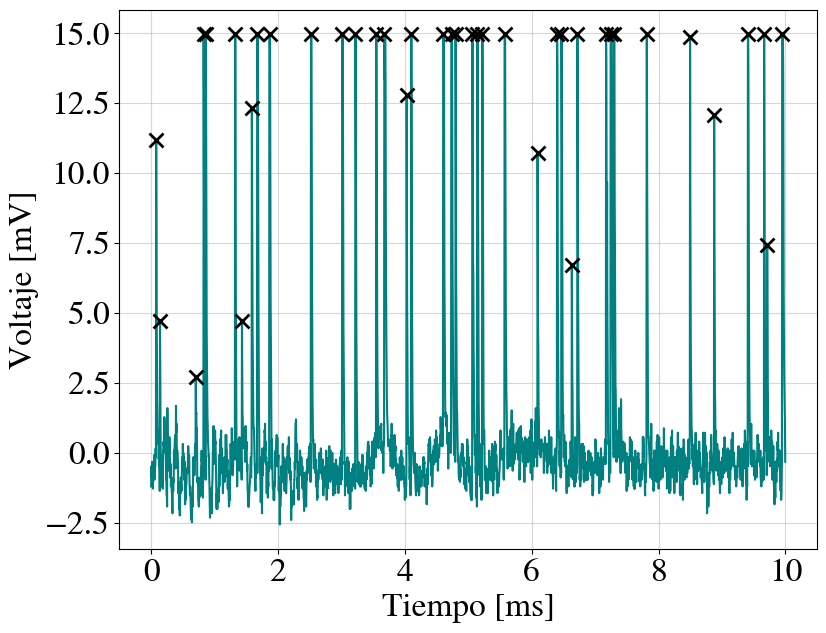

In [ ]:
cuentas = []

for n in np.arange(1,total_pantallas, 1):

    picos, diccionario = find_peaks(-voltaje[n], height = umbral, prominence = 0.0001, distance = 5)
    #print(n)
    if n < 10:
        plt.plot(tiempo[n]*1000, - voltaje[n]*1000, color = 'teal')
        plt.plot(tiempo[n][picos]*1000, -voltaje[n][picos]*1000, marker = 'x', markersize = 10, linestyle = '', color = 'black', mew = 2)

        plt.ylabel(f'Voltaje [mV]')
        plt.xlabel(f'Tiempo [ms]')
        plt.show()

    cuentas.append(len(picos))



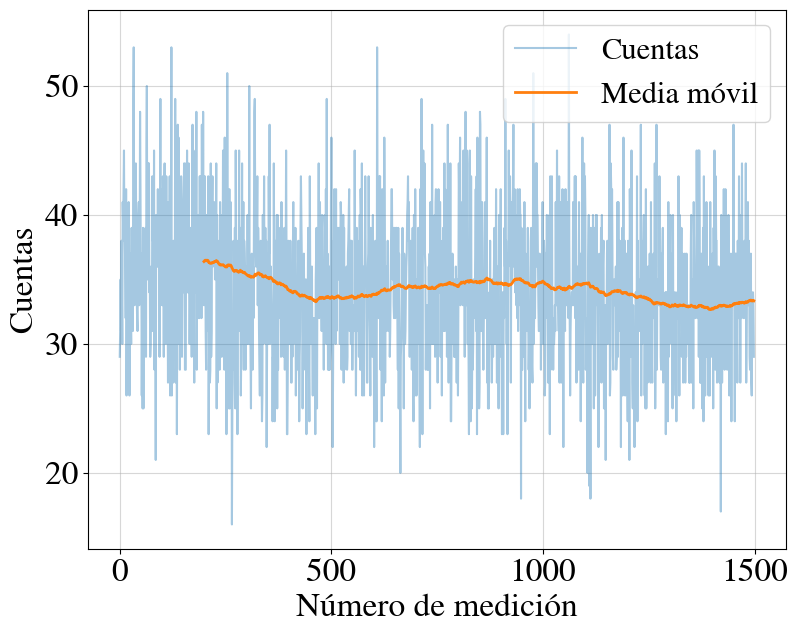

In [ ]:
def media_movil(x, ventana):
    kernel = np.ones(ventana) / ventana
    return np.convolve(x, kernel, mode='valid')

ventana = 200   # número de mediciones que promedias
mm = media_movil(cuentas, ventana)

plt.figure()
plt.plot(cuentas, alpha=0.4, label="Cuentas")
plt.plot(np.arange(ventana-1, len(cuentas)), mm, linewidth=2, label="Media móvil")
plt.xlabel("Número de medición")
plt.ylabel("Cuentas")
plt.legend()

Text(0, 0.5, 'cuentas')

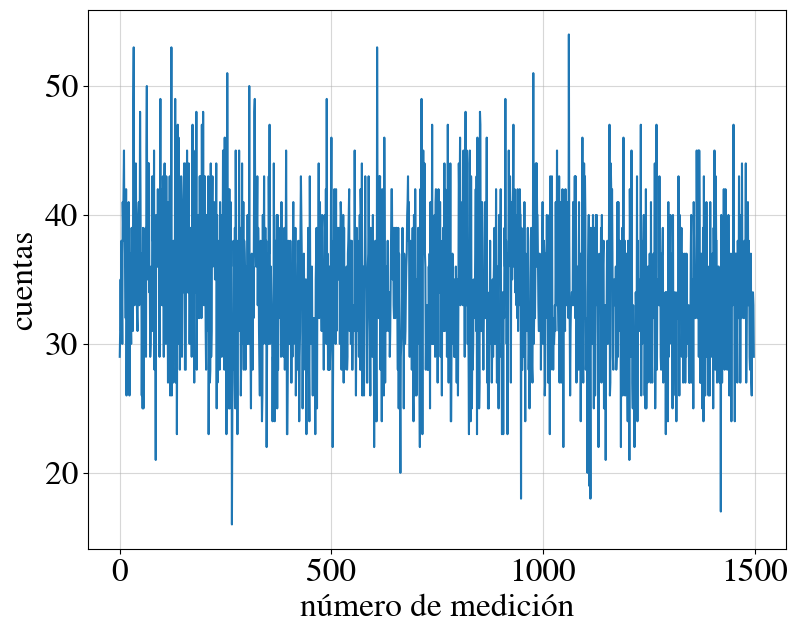

In [ ]:
plt.plot(cuentas)
plt.xlabel("número de medición")
plt.ylabel("cuentas")

la media es 34.29819879919947, la varianza 33.45544038476174
la tasa es 3429.82 fotones por segundo


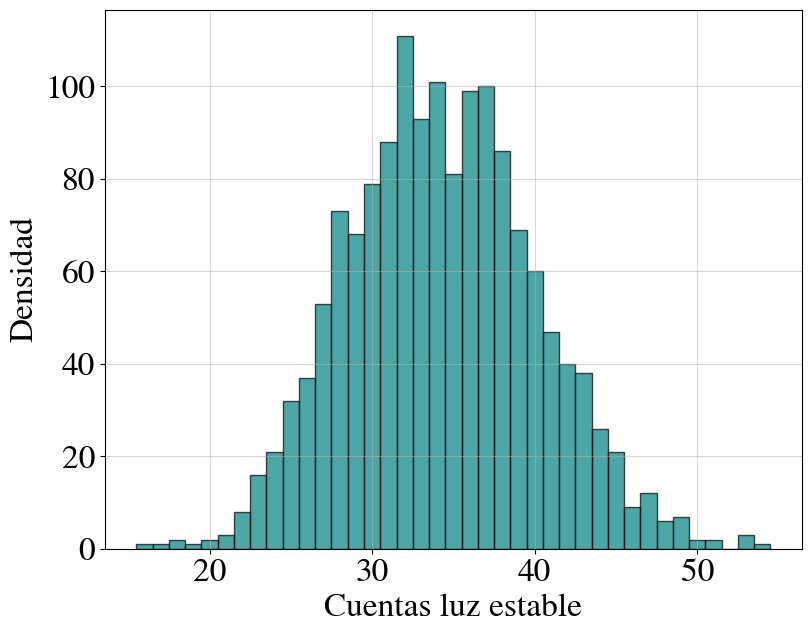

In [ ]:
plt.hist(cuentas, density = False, color = 'teal', alpha = 0.7, edgecolor='black', bins = np.arange(min(cuentas) - 0.5, max(cuentas) + 1.5, 1))
plt.xlabel('Cuentas luz estable')
plt.ylabel('Densidad')

media = np.mean(cuentas)
varianza = np.var(cuentas, ddof = 0)
sampleo = np.random.poisson(media, len(cuentas))

print(f'la media es {media}, la varianza {varianza}')
print(f'la tasa es {media/0.01:.2f} fotones por segundo')

In [ ]:
var = 1/len(cuentas) * np.sum((cuentas - np.mean(cuentas))**2)

var

np.float64(33.45544038476174)

#Testeo con lo esperado

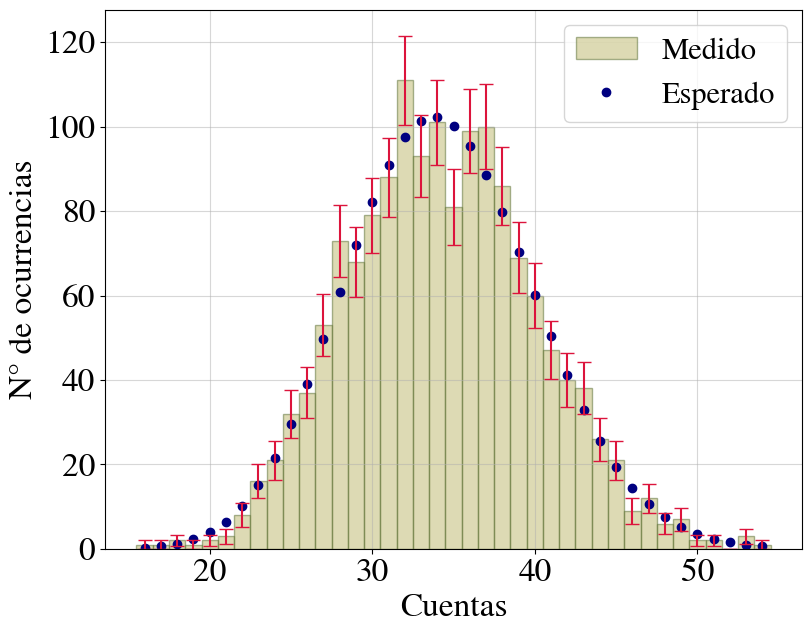

In [ ]:
def fun_poisson(k, tasa):
    return ((tasa ** k ) / factorial(k) ) * np.exp(-tasa)

k = np.arange(min(cuentas), max(cuentas)+1)
esperado = len(cuentas) * fun_poisson(k, np.mean(cuentas)) #frecuencia de aparicion esperada N*Pk


alturas = np.array([np.sum(cuentas == j) for j in k])
x = np.arange(min(cuentas), max(cuentas)+1, 1)

plt.hist(cuentas, density = False, color = 'darkkhaki', alpha = 0.5, edgecolor='darkolivegreen', bins = np.arange(min(cuentas) - 0.5, max(cuentas) + 1.5, 1), label = 'Medido')
plt.plot(k, esperado, marker = 'o', color = 'navy', linestyle = '', label = 'Esperado')
plt.errorbar(x, alturas, fmt = '', c = 'crimson', linestyle = '', yerr = np.sqrt(alturas), capsize = 5, )
plt.xlabel('Cuentas')
plt.ylabel('N° de ocurrencias')
plt.savefig('laser_estable.pdf')
plt.legend()


##Montecarlo


In [ ]:
estad_med = np.sum( (alturas - esperado)**2  / esperado)

def montecarlo(cantidad, media, k, esperado, N):
    estadistico = []

    for _ in range(cantidad):
        va = np.random.poisson(media, N)

        alt = np.array([np.sum(va == j) for j in k])

        estad = np.sum((alt - esperado)**2 / esperado)
        estadistico.append(estad)

    return np.array(estadistico)

estad_sampleo = montecarlo(100000, media, k, esperado, 1500)

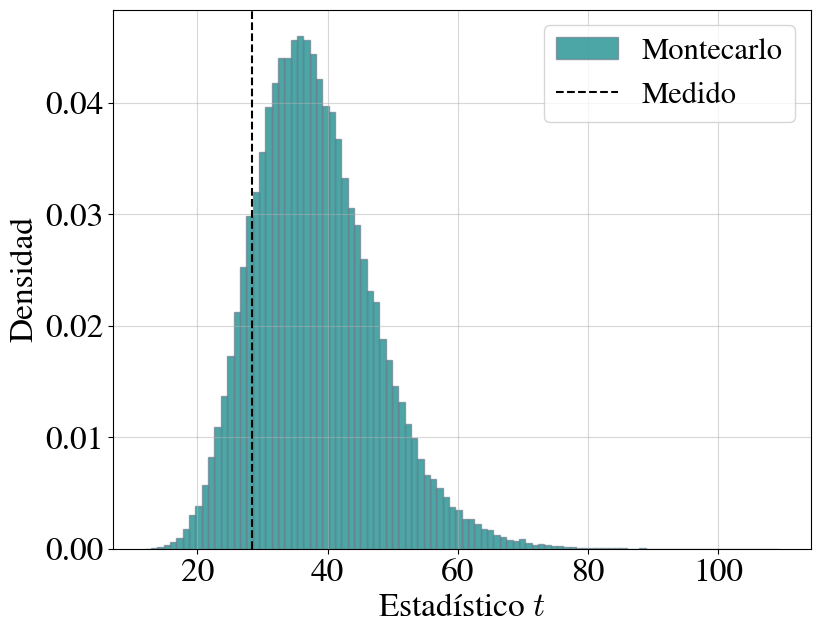

In [ ]:
estad_med_var_med = np.sum( (alturas - esperado)**2  / varianza)

plt.hist(estad_sampleo, density = True,color = 'teal', alpha = 0.7, edgecolor='slategray', bins = 100, label = 'Montecarlo')
plt.axvline(estad_med, color = 'black', linestyle = '--', label = 'Medido')
#plt.axvline(estad_med_var_med, color = 'crimson', linestyle = '--', label = 'Con VAR medida')

plt.xlabel(r'Estadístico $t$')
plt.ylabel('Densidad')


plt.legend()

plt.savefig('montecarlo_estable.pdf')

plt.show()

##Pvalor y cosas

In [ ]:
media_esperada = np.mean(estad_sampleo)
desv_esperada = np.std(estad_sampleo, ddof = 1)
cant_sigmas = (estad_med - media_esperada)/desv_esperada
cant_sigmas_var_med = (estad_med_var_med - media_esperada)/desv_esperada


print(f'El valor esperado del estadístico es {media_esperada:.2f} con desviación {desv_esperada:.2f}')
print(f'El estadístico medido está a {cant_sigmas:.2f} del valor esperado')
print(f'El estadístico medido tomando la varianza medida está a {cant_sigmas_var_med:.2f} del valor esperado')

pvalor = np.mean(estad_sampleo >= estad_med)

pvalor

El valor esperado del estadístico es 38.08 con desviación 9.28
El estadístico medido está a -1.04 del valor esperado
El estadístico medido tomando la varianza medida está a -0.48 del valor esperado


np.float64(0.86118)